In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
path=r"D:\项目\自我监测系统项目\苹果手表导出数据\2026-02-27.xml"
print("文件读取成功")

文件读取成功


In [3]:
tree=ET.parse(path)
root=tree.getroot()

In [4]:
df = pd.DataFrame([list.attrib for list in root.iter('Record')])

In [5]:
print(f"表格大小{df.shape}")
print(f"列名{df.columns}")
print(f"行名{df.index}")
print(f"type:{df['type'].unique()}")

表格大小(40514, 9)
列名Index(['type', 'sourceName', 'sourceVersion', 'unit', 'creationDate',
       'startDate', 'endDate', 'value', 'device'],
      dtype='object')
行名RangeIndex(start=0, stop=40514, step=1)
type:['HKQuantityTypeIdentifierHeight' 'HKQuantityTypeIdentifierBodyMass'
 'HKQuantityTypeIdentifierHeartRate'
 'HKQuantityTypeIdentifierOxygenSaturation'
 'HKQuantityTypeIdentifierRespiratoryRate'
 'HKQuantityTypeIdentifierStepCount'
 'HKQuantityTypeIdentifierDistanceWalkingRunning'
 'HKQuantityTypeIdentifierBasalEnergyBurned'
 'HKQuantityTypeIdentifierActiveEnergyBurned'
 'HKQuantityTypeIdentifierFlightsClimbed'
 'HKQuantityTypeIdentifierAppleExerciseTime'
 'HKQuantityTypeIdentifierRestingHeartRate'
 'HKQuantityTypeIdentifierWalkingHeartRateAverage'
 'HKQuantityTypeIdentifierEnvironmentalAudioExposure'
 'HKQuantityTypeIdentifierHeadphoneAudioExposure'
 'HKQuantityTypeIdentifierWalkingDoubleSupportPercentage'
 'HKQuantityTypeIdentifierAppleStandTime'
 'HKQuantityTypeIdentifierWalkingSpe

False    38633
True      1881
Name: count, dtype: int64


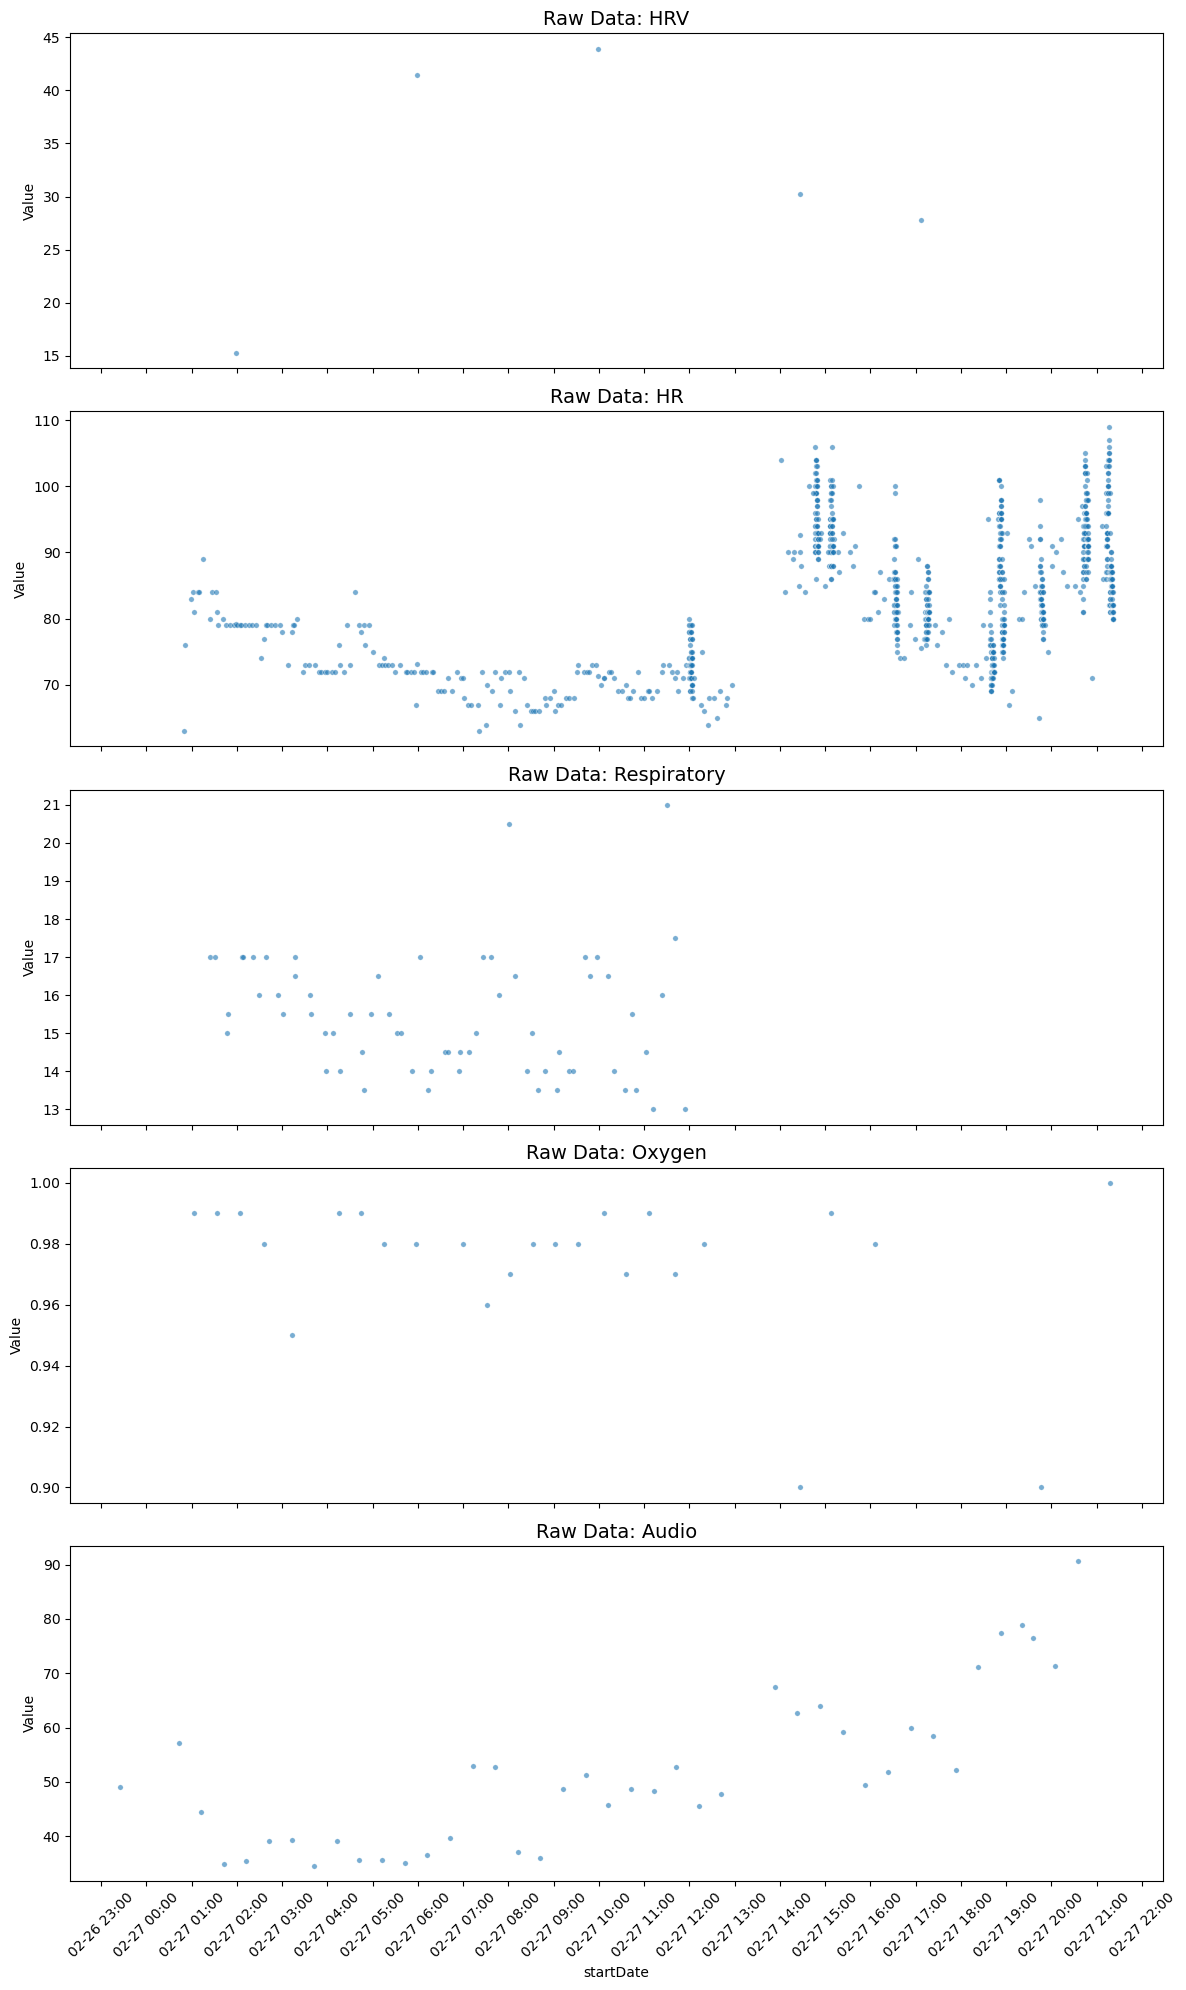

In [12]:
df['startDate'] = pd.to_datetime(df['startDate']).dt.tz_localize(None)
df['endDate'] = pd.to_datetime(df['endDate']).dt.tz_localize(None)
start_time=pd.to_datetime('2026-02-26 23:00:00')
end_time = pd.to_datetime('2026-02-27 22:00:00')
mask = (df['startDate'] >= start_time) & (df['endDate'] <= end_time)

print(mask.value_counts())

RecordDF=df.loc[mask].copy()
RecordDF['value']=pd.to_numeric(RecordDF['value'],errors='coerce')

RecordDF['startDate'] = RecordDF['startDate'].dt.tz_localize(None)
RecordDF['endDate'] = RecordDF['endDate'].dt.tz_localize(None)



target_signals={
    'HRV': 'HKQuantityTypeIdentifierHeartRateVariabilitySDNN',
    'HR': 'HKQuantityTypeIdentifierHeartRate',
    'Respiratory': 'HKQuantityTypeIdentifierRespiratoryRate',
    'Oxygen': 'HKQuantityTypeIdentifierOxygenSaturation',
    'Audio': 'HKQuantityTypeIdentifierEnvironmentalAudioExposure'
}


fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=True)

for i, (name, identifier) in enumerate(target_signals.items()):

    data = RecordDF[RecordDF['type'] == identifier]
    sns.scatterplot(data=data, x='startDate', y='value', ax=axes[i], s=15, alpha=0.6)

    axes[i].xaxis.set_major_locator(mdates.HourLocator(interval=1))

    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    
    axes[i].set_title(f'Raw Data: {name}', fontsize=14)
    axes[i].set_ylabel('Value')
    

    axes[i].tick_params(axis='x', rotation=45) 

plt.tight_layout()

plt.show()

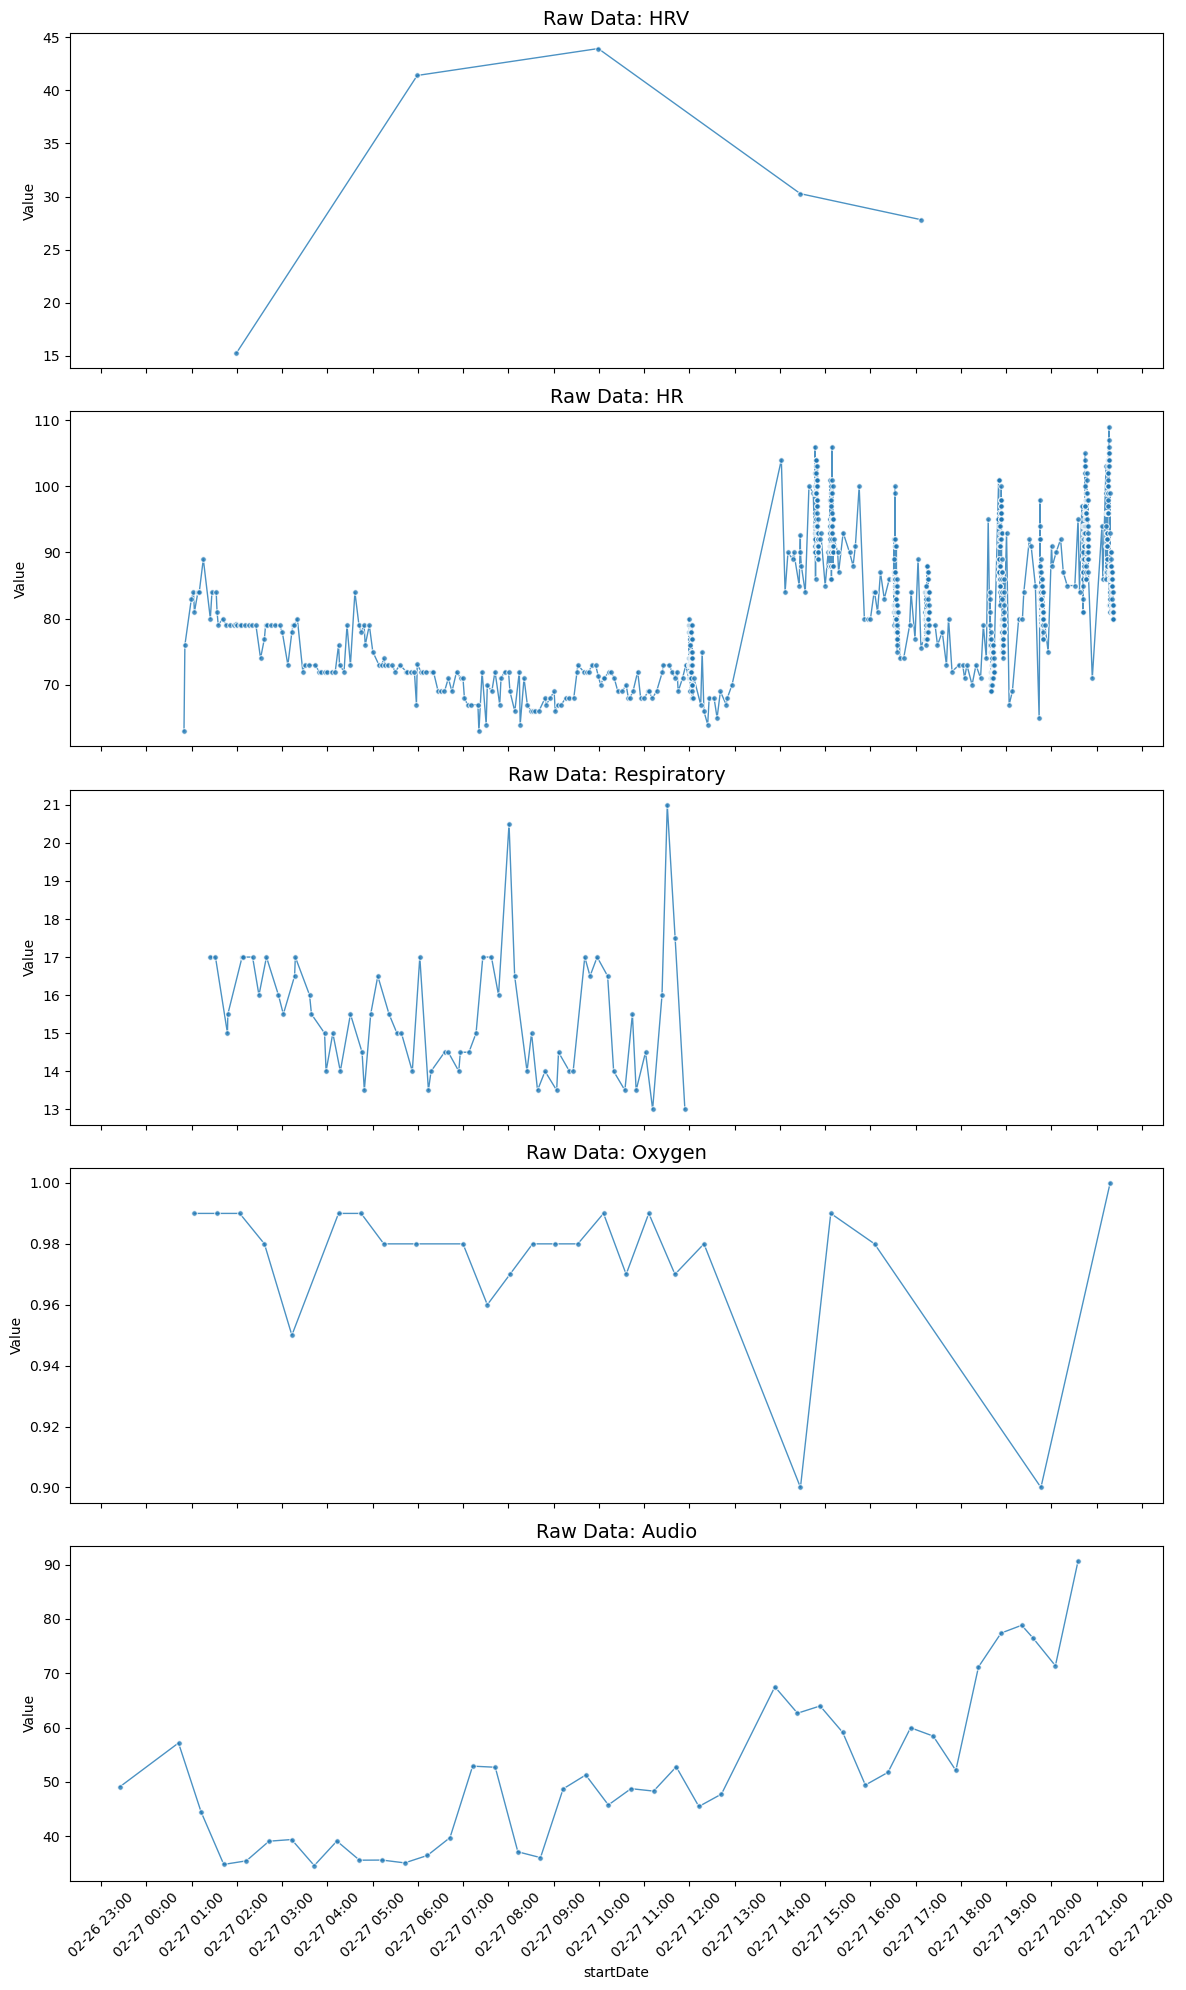

In [13]:
fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=True)

for i, (name, identifier) in enumerate(target_signals.items()):

    data = RecordDF[RecordDF['type'] == identifier]
    sns.lineplot(data=data, x='startDate', y='value', ax=axes[i], marker='o', markersize=4, linewidth=1, alpha=0.8)

    axes[i].xaxis.set_major_locator(mdates.HourLocator(interval=1))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    
    axes[i].set_title(f'Raw Data: {name}', fontsize=14)
    axes[i].set_ylabel('Value')
    

    axes[i].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

C:\Users\Kora1\AppData\Local\Temp\ipykernel_25800\4161710222.py:33: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
F:\Ana\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


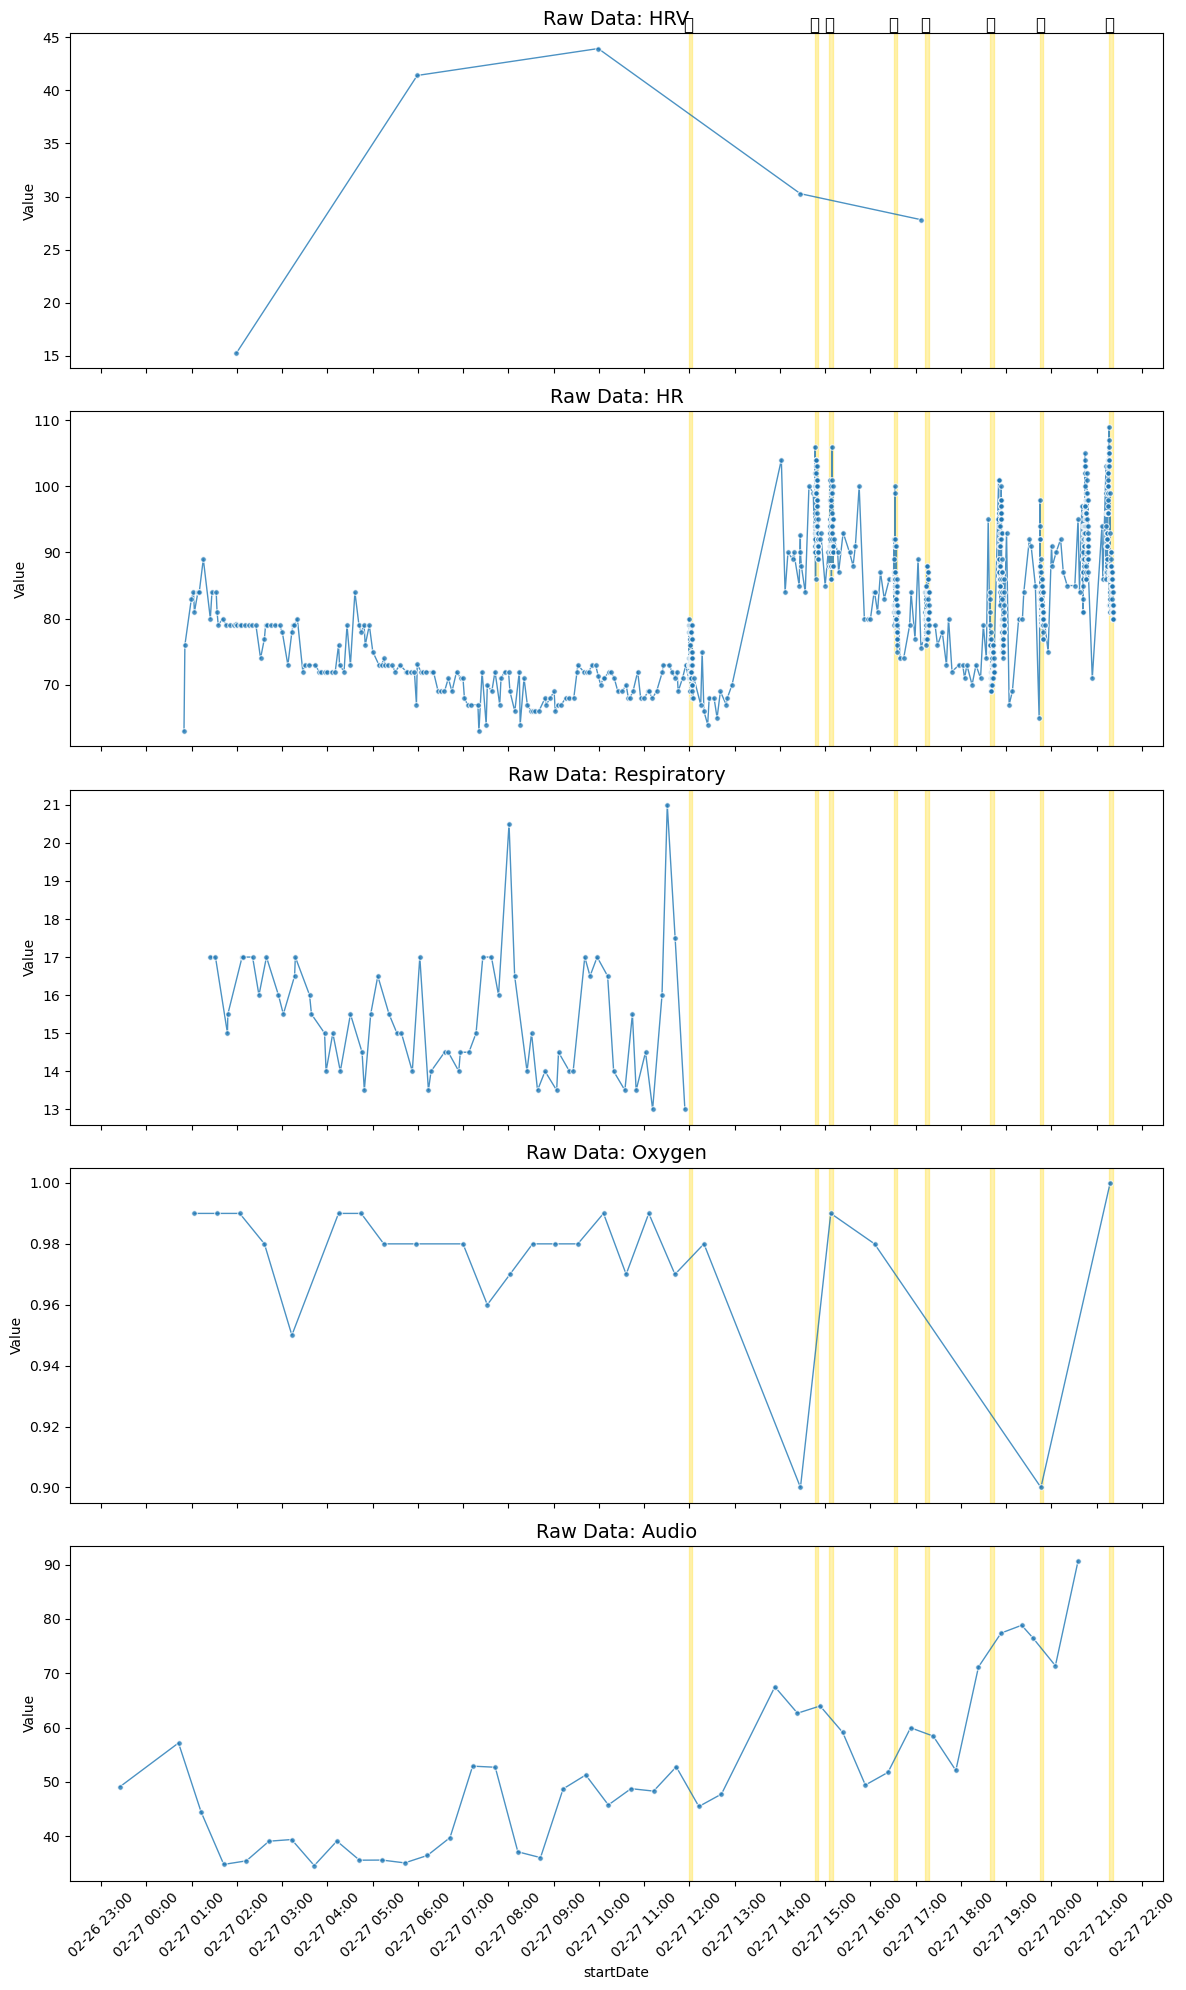

In [14]:
#将八次5分钟正念的情况记录到全天数据当中
mindful_data = df[df['type'] == 'HKCategoryTypeIdentifierMindfulSession'].copy()
mindful_data['startDate'] = pd.to_datetime(mindful_data['startDate'])
mindful_data['endDate'] = pd.to_datetime(mindful_data['endDate'])

fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=True)

for i, (name, identifier) in enumerate(target_signals.items()):

    data = RecordDF[RecordDF['type'] == identifier]
    sns.lineplot(data=data, x='startDate', y='value', ax=axes[i], marker='o', markersize=4, linewidth=1, alpha=0.8)

    axes[i].xaxis.set_major_locator(mdates.HourLocator(interval=1))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    
    axes[i].set_title(f'Raw Data: {name}', fontsize=14)
    axes[i].set_ylabel('Value')
    

    axes[i].tick_params(axis='x', rotation=45) 
#--------------------正念添加--------------------
    for _, session in mindful_data.iterrows():
        # 用金黄色 (Gold) 代表正念，alpha 设置高一点方便识别
        axes[i].axvspan(session['startDate'], session['endDate'], 
                        color='gold', alpha=0.3, label='Mindfulness')
        
        # 只在第一张图顶部标注 "M" (Mindfulness)
        if i == 0:
            axes[i].text(session['startDate'], axes[i].get_ylim()[1], '🧘', 
                         ha='center', va='bottom', fontsize=12)    
#-------------------------------------------------------------------------------

plt.tight_layout()
plt.show()
